In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [10]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\agarw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
import os
print(os.getcwd())

C:\Users\agarw


In [15]:
import pandas as pd
import os

print("Current folder:", os.getcwd())

file_path = r'C:\Users\agarw\Desktop\rfm_project\online_retail_II.csv'

df = pd.read_csv(file_path)

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

Current folder: C:\Users\agarw
(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country 

In [16]:

df = df.dropna(subset=['Customer ID'])

print(f"Rows after removing null CustomerIDs: {len(df)}")

Rows after removing null CustomerIDs: 824364


In [17]:
print(df.shape)

(824364, 8)


In [18]:
print(df.dtypes)
print(df.isnull().sum())

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [19]:

df = df[~df['Invoice'].astype(str).str.startswith('C')]

print(f"Rows after removing cancellations: {len(df)}")

Rows after removing cancellations: 805620


In [20]:

df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print(f"Final clean rows: {len(df)}")

Final clean rows: 805549


In [21]:
df['Revenue'] = df['Quantity'] * df['Price']

print(df[['Invoice', 'Quantity', 'Price', 'Revenue']].head())

  Invoice  Quantity  Price  Revenue
0  489434        12   6.95     83.4
1  489434        12   6.75     81.0
2  489434        12   6.75     81.0
3  489434        48   2.10    100.8
4  489434        24   1.25     30.0


In [22]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

Reference date: 2011-12-10 12:50:00


In [23]:
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head(10))
print(rfm.describe())

   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40
5      12351.0      375          1    300.93
6      12352.0       36         10   2849.84
7      12353.0      204          2    406.76
8      12354.0      232          1   1079.40
9      12355.0      214          2    947.61
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.0000

In [24]:
# Score Recency — lower days = higher score (5 is best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])

# Score Frequency — higher = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                          q=5, labels=[1,2,3,4,5])

# Score Monetary — higher = better
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 
                          q=5, labels=[1,2,3,4,5])

rfm[['R_Score','F_Score','M_Score']] = rfm[['R_Score','F_Score','M_Score']].astype(int)

# Combined RFM Score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346.0      326         12  77556.46        2        5        5   
1      12347.0        2          8   5633.32        5        4        5   
2      12348.0       75          5   2019.40        3        4        4   
3      12349.0       19          4   4428.69        5        3        5   
4      12350.0      310          1    334.40        2        1        2   

  RFM_Score  
0       255  
1       545  
2       344  
3       535  
4       212  


In [25]:
def segment_customer(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalist'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal Customer        1403
Champion              1300
Lost                  1275
At Risk                824
Potential Loyalist     633
New Customer           443
Name: count, dtype: int64


In [26]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2).reset_index()


segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] / 
    segment_summary['Total_Revenue'].sum() * 100
).round(2)

print(segment_summary)

              Segment  Customer_Count  Avg_Recency  Avg_Frequency  \
0             At Risk             824       369.10           4.94   
1            Champion            1300        19.97          17.09   
2                Lost            1275       467.79           1.19   
3      Loyal Customer            1403        71.39           5.42   
4        New Customer             443        28.11           1.46   
5  Potential Loyalist             633       227.94           1.45   

   Avg_Monetary  Total_Revenue  Revenue_%  
0       1982.98     1633975.49       9.21  
1       9329.32    12128115.56      68.35  
2        256.98      327643.25       1.85  
3       1934.40     2713960.75      15.30  
4        890.83      394638.61       2.22  
5        861.13      545095.51       3.07  


C:\Users\agarw\AppData\Local\Temp\ipykernel_21876\2754208932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=order, palette='Greens_r')


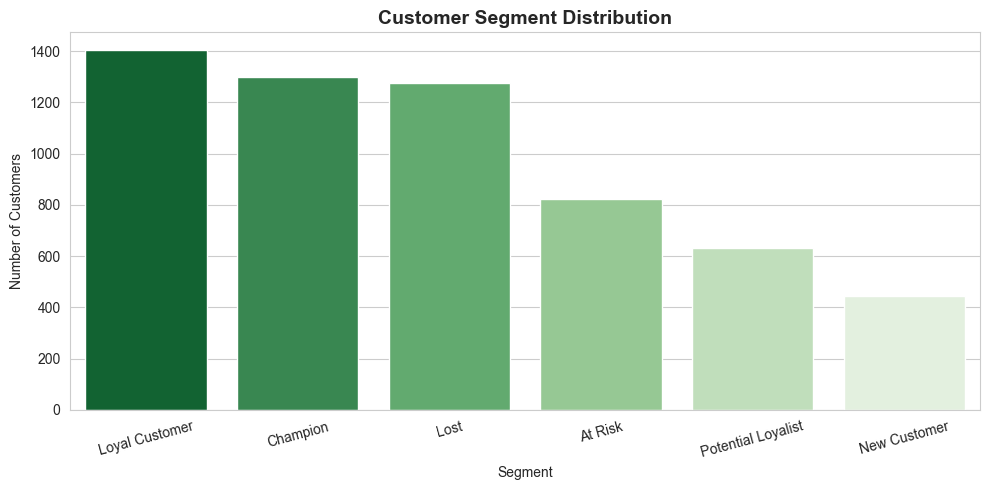

In [27]:
plt.figure(figsize=(10,5))
order = rfm['Segment'].value_counts().index
sns.countplot(data=rfm, x='Segment', order=order, palette='Greens_r')
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150)
plt.show()

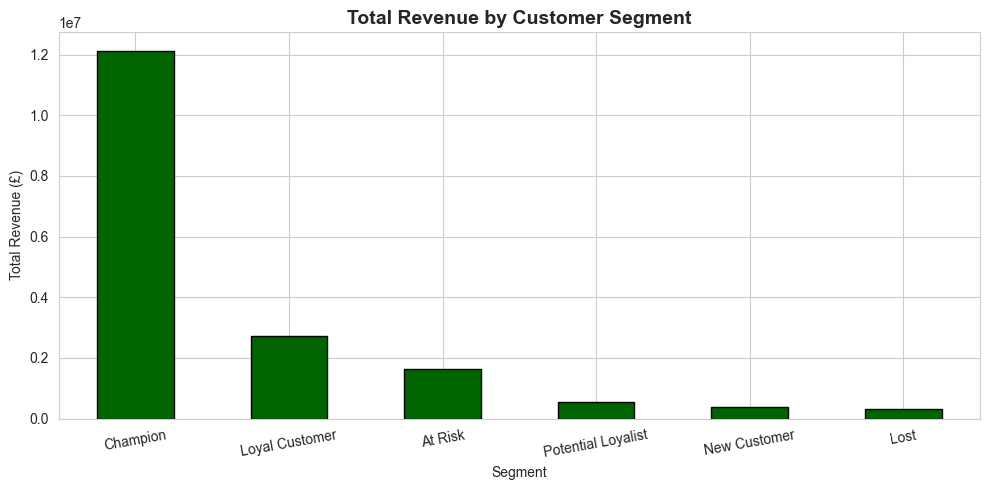

In [28]:
plt.figure(figsize=(10,5))
revenue_data = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
revenue_data.plot(kind='bar', color='darkgreen', edgecolor='black')
plt.title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=150)
plt.show()

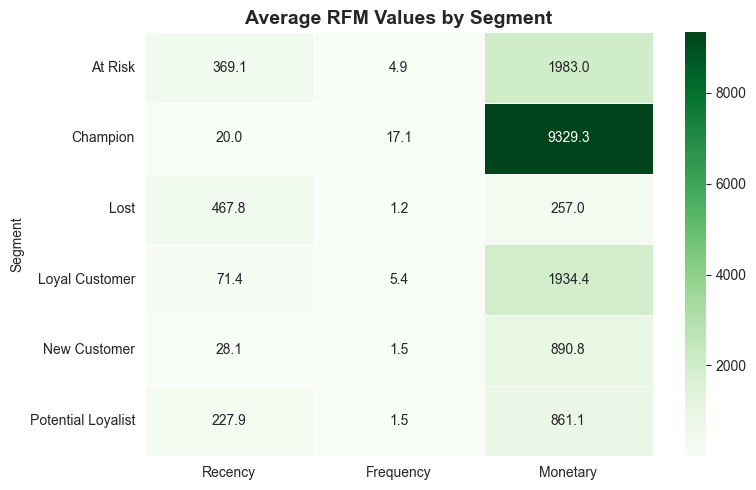

In [29]:
heatmap_data = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Greens', linewidths=0.5)
plt.title('Average RFM Values by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150)
plt.show()

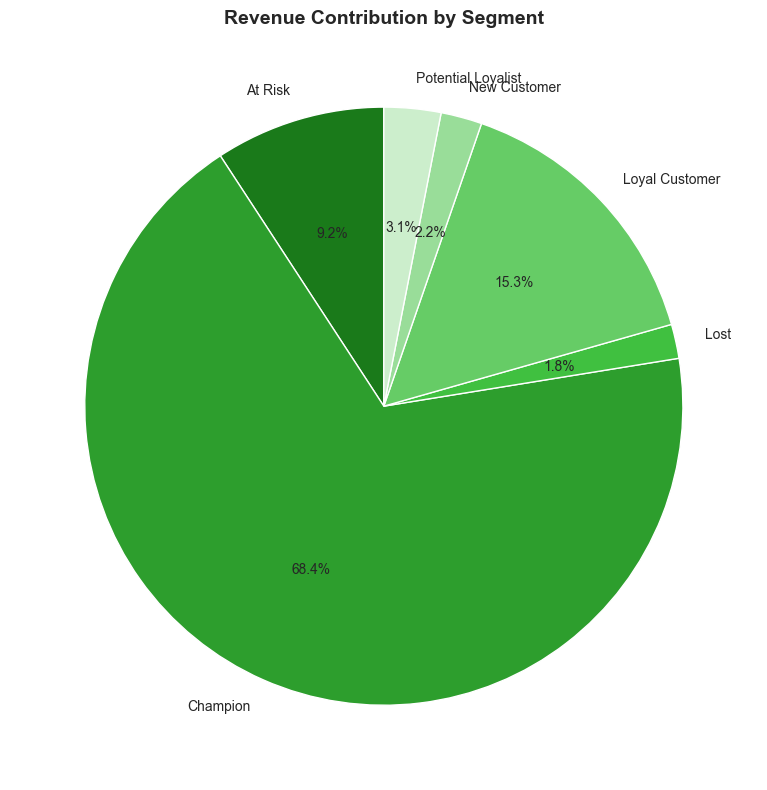

In [30]:
plt.figure(figsize=(8,8))
segment_summary.set_index('Segment')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#1a7a1a','#2d9e2d','#40c040','#66cc66','#99dd99','#cceecc'],
    startangle=90
)
plt.title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('revenue_pie.png', dpi=150)
plt.show()

## 💡 Business Recommendations by Segment

| Segment | Strategy |
|---|---|
| Champions | Reward with loyalty program, early access to new products |
| Loyal Customers | Upsell premium products, ask for reviews |
| New Customers | Onboarding offers, guide to explore categories |
| Potential Loyalists | Membership offers, personalized recommendations |
| At Risk | Send win-back campaigns, offer limited discounts |
| Lost | Aggressive re-engagement or deprioritize marketing spend |

In [31]:

rfm.to_excel('RFM_Segments.xlsx', index=False)


segment_summary.to_excel('Segment_Summary.xlsx', index=False)

print("Files saved successfully!")

Files saved successfully!
